# 04 - Visualization Dashboard
**Goal:** Combine all findings from notebook 03 into clean, presentation-ready dashboard figures.

Each section produces a self-contained multi-panel figure that can be saved and shared.

**Input:** `data/processed/analysis_ready.csv` + `data/processed/account_profiles.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
SENTIMENT_ORDER  = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
SENTIMENT_COLORS = ['#d73027', '#fc8d59', '#fee08b', '#91cf60', '#1a9850']
COLOR_MAP        = dict(zip(SENTIMENT_ORDER, SENTIMENT_COLORS))
TIER_COLORS      = {'Losing': '#e74c3c', 'Break-even': '#f39c12', 'Profitable': '#2ecc71'}

PROCESSED_DIR = '../data/processed/'
FIG_DIR       = '../figures/'
os.makedirs(FIG_DIR, exist_ok=True)

In [3]:
df = pd.read_csv(os.path.join(PROCESSED_DIR, 'analysis_ready.csv'), parse_dates=['date'])
ap = pd.read_csv(os.path.join(PROCESSED_DIR, 'account_profiles.csv'))

# Fix trader_tier collision if present
if 'trader_tier_x' in df.columns:
    df.rename(columns={'trader_tier_x': 'trader_tier'}, inplace=True)
    df.drop(columns=['trader_tier_y'], errors='ignore', inplace=True)

# Restore ordered categories
df['fg_label']    = pd.Categorical(df['fg_label'],    categories=SENTIMENT_ORDER, ordered=True)
df['trader_tier'] = pd.Categorical(df['trader_tier'],
                                   categories=['Losing','Break-even','Profitable'], ordered=True)
ap['trader_tier'] = pd.Categorical(ap['trader_tier'],
                                   categories=['Losing','Break-even','Profitable'], ordered=True)

# Daily aggregate (date-level)
daily = (
    df.groupby('date')
    .agg(
        total_pnl    = ('net_pnl',     'sum'),
        median_pnl   = ('net_pnl_w',   'median'),
        total_volume = ('total_volume', 'sum'),
        avg_win_rate = ('is_win',       'mean'),
        fg_value     = ('fg_value',     'first'),
        fg_label     = ('fg_label',     'first'),
        fg_7d_ma     = ('fg_7d_ma',     'first'),
    )
    .reset_index()
    .sort_values('date')
)

# Lag features for dashboard
for lag in [1, 2, 3]:
    daily[f'fg_lag{lag}'] = daily['fg_value'].shift(lag)
daily.dropna(inplace=True)

print(f'Main df  : {df.shape}')
print(f'Profiles : {ap.shape}')
print(f'Daily    : {daily.shape}')

Main df  : (2340, 38)
Profiles : (32, 13)
Daily    : (476, 11)


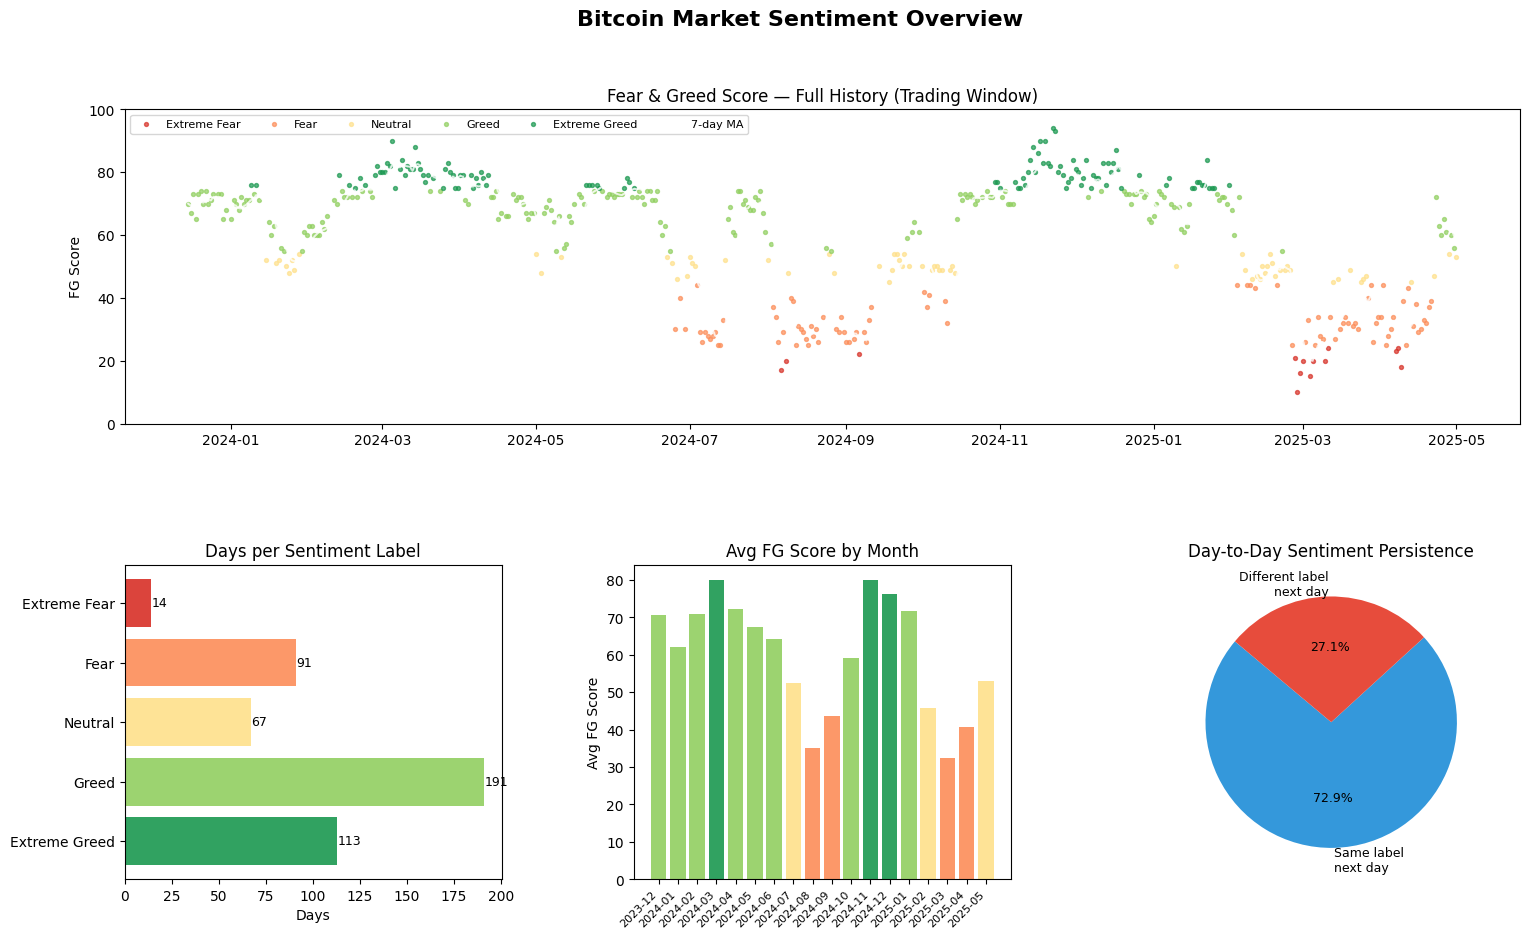

Saved: dashboard_1_sentiment_overview.png


In [4]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle('Bitcoin Market Sentiment Overview',
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel A: FG score timeline
ax_a = fig.add_subplot(gs[0, :])
for label in SENTIMENT_ORDER:
    sub = daily[daily['fg_label'] == label]
    ax_a.scatter(sub['date'], sub['fg_value'],
                 color=COLOR_MAP[label], s=8, alpha=0.7, label=label)
ax_a.plot(daily['date'], daily['fg_7d_ma'],
          color='white', linewidth=1.4, alpha=0.8, label='7-day MA')
ax_a.set(title='Fear & Greed Score — Full History (Trading Window)',
         ylabel='FG Score', ylim=(0, 100))
ax_a.legend(fontsize=8, ncol=6, loc='upper left')

#  Panel B: Label distribution bar 
ax_b = fig.add_subplot(gs[1, 0])
counts = daily['fg_label'].value_counts().reindex(SENTIMENT_ORDER).fillna(0)
ax_b.barh(counts.index, counts.values,
          color=SENTIMENT_COLORS, edgecolor='none', alpha=0.9)
ax_b.set(title='Days per Sentiment Label', xlabel='Days', ylabel='')
ax_b.invert_yaxis()
for i, (label, val) in enumerate(counts.items()):
    ax_b.text(val + 0.3, i, f'{int(val)}', va='center', fontsize=9)

# Panel C: Average FG score by month 
ax_c = fig.add_subplot(gs[1, 1])
daily['month'] = daily['date'].dt.to_period('M').astype(str)
monthly_fg = daily.groupby('month')['fg_value'].mean()
bar_colors_m = [
    '#d73027' if v < 25 else
    '#fc8d59' if v < 45 else
    '#fee08b' if v < 55 else
    '#91cf60' if v < 75 else
    '#1a9850'
    for v in monthly_fg.values
]
ax_c.bar(range(len(monthly_fg)), monthly_fg.values,
         color=bar_colors_m, edgecolor='none', alpha=0.9)
ax_c.set_xticks(range(len(monthly_fg)))
ax_c.set_xticklabels(monthly_fg.index, rotation=45, ha='right', fontsize=8)
ax_c.set(title='Avg FG Score by Month', ylabel='Avg FG Score')

# ── Panel D: Sentiment transitions (prev → next) ──────────────────────────
ax_d = fig.add_subplot(gs[1, 2])
daily['next_label'] = daily['fg_label'].shift(-1)
stayed = (daily['fg_label'] == daily['next_label']).sum()
changed = (daily['fg_label'] != daily['next_label']).sum()
ax_d.pie([stayed, changed],
         labels=['Same label\nnext day', 'Different label\nnext day'],
         colors=['#3498db', '#e74c3c'],
         autopct='%1.1f%%', startangle=140,
         textprops={'fontsize': 9})
ax_d.set_title('Day-to-Day Sentiment Persistence')

plt.savefig(os.path.join(FIG_DIR, 'dashboard_1_sentiment_overview.png'))
plt.show()
print('Saved: dashboard_1_sentiment_overview.png')

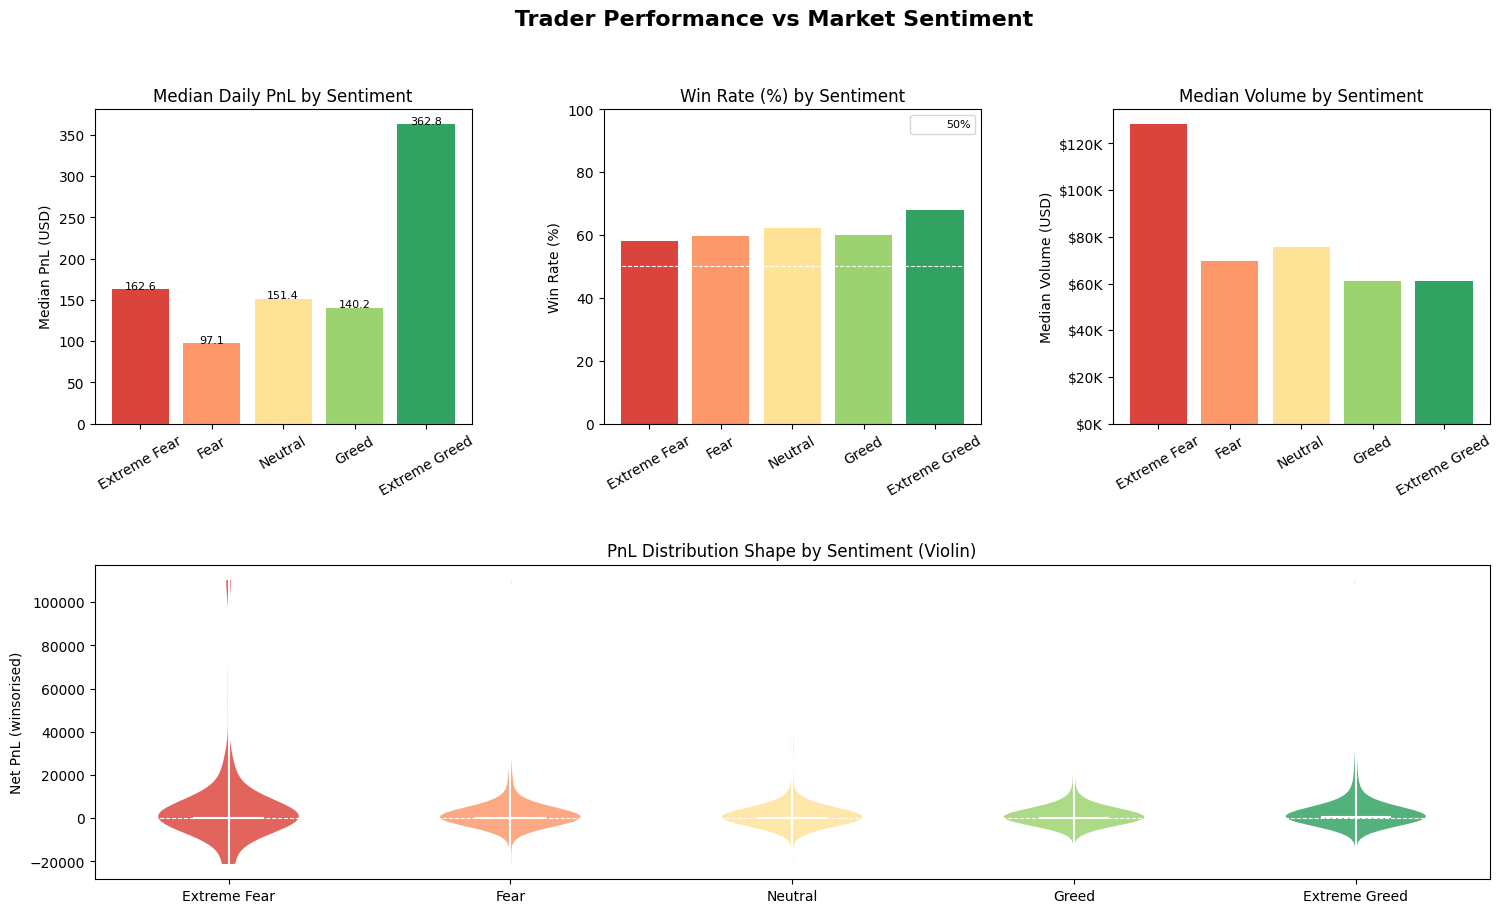

 Saved: dashboard_2_performance_vs_sentiment.png


In [5]:
# Pre-compute aggregates
pnl_by_sent = (
    df.groupby('fg_label', observed=True)
    .agg(median_pnl=('net_pnl_w','median'),
         win_rate=('is_win','mean'),
         median_volume=('total_volume_w','median'))
    .reset_index()
)

fig = plt.figure(figsize=(18, 10))
fig.suptitle('' \
' Trader Performance vs Market Sentiment',
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

colors = [COLOR_MAP[l] for l in pnl_by_sent['fg_label']]

# Panel A: Median PnL by sentiment 
ax_a = fig.add_subplot(gs[0, 0])
bars = ax_a.bar(pnl_by_sent['fg_label'], pnl_by_sent['median_pnl'],
                color=colors, edgecolor='none', alpha=0.9)
ax_a.axhline(0, color='white', linewidth=0.8, linestyle='--')
ax_a.set(title='Median Daily PnL by Sentiment',
         xlabel='', ylabel='Median PnL (USD)')
ax_a.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, pnl_by_sent['median_pnl']):
    ax_a.text(bar.get_x() + bar.get_width()/2,
              val + (0.5 if val >= 0 else -1.5),
              f'{val:.1f}', ha='center', fontsize=8)

#  Panel B: Win rate by sentiment 
ax_b = fig.add_subplot(gs[0, 1])
ax_b.bar(pnl_by_sent['fg_label'], pnl_by_sent['win_rate'] * 100,
         color=colors, edgecolor='none', alpha=0.9)
ax_b.axhline(50, color='white', linewidth=0.8, linestyle='--', label='50%')
ax_b.set(title='Win Rate (%) by Sentiment',
         xlabel='', ylabel='Win Rate (%)', ylim=(0, 100))
ax_b.tick_params(axis='x', rotation=30)
ax_b.legend(fontsize=8)

# Panel C: Median volume by sentiment 
ax_c = fig.add_subplot(gs[0, 2])
ax_c.bar(pnl_by_sent['fg_label'], pnl_by_sent['median_volume'],
         color=colors, edgecolor='none', alpha=0.9)
ax_c.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'${x/1e3:.0f}K'
))
ax_c.set(title='Median Volume by Sentiment',
         xlabel='', ylabel='Median Volume (USD)')
ax_c.tick_params(axis='x', rotation=30)

#  Panel D: PnL distribution violin by sentiment 
ax_d = fig.add_subplot(gs[1, :])
parts = ax_d.violinplot(
    [df[df['fg_label'] == lbl]['net_pnl_w'].dropna().values
     for lbl in SENTIMENT_ORDER],
    positions=range(len(SENTIMENT_ORDER)),
    showmedians=True, showextrema=True
)
for i, (pc, color) in enumerate(zip(parts['bodies'], SENTIMENT_COLORS)):
    pc.set_facecolor(color)
    pc.set_alpha(0.75)
parts['cmedians'].set_color('white')
parts['cmaxes'].set_color('white')
parts['cmins'].set_color('white')
parts['cbars'].set_color('white')
ax_d.set_xticks(range(len(SENTIMENT_ORDER)))
ax_d.set_xticklabels(SENTIMENT_ORDER)
ax_d.axhline(0, color='white', linewidth=0.8, linestyle='--')
ax_d.set(title='PnL Distribution Shape by Sentiment (Violin)',
         ylabel='Net PnL (winsorised)')

plt.savefig(os.path.join(FIG_DIR, 'dashboard_2_performance_vs_sentiment.png'))
plt.show()
print(' Saved: dashboard_2_performance_vs_sentiment.png')

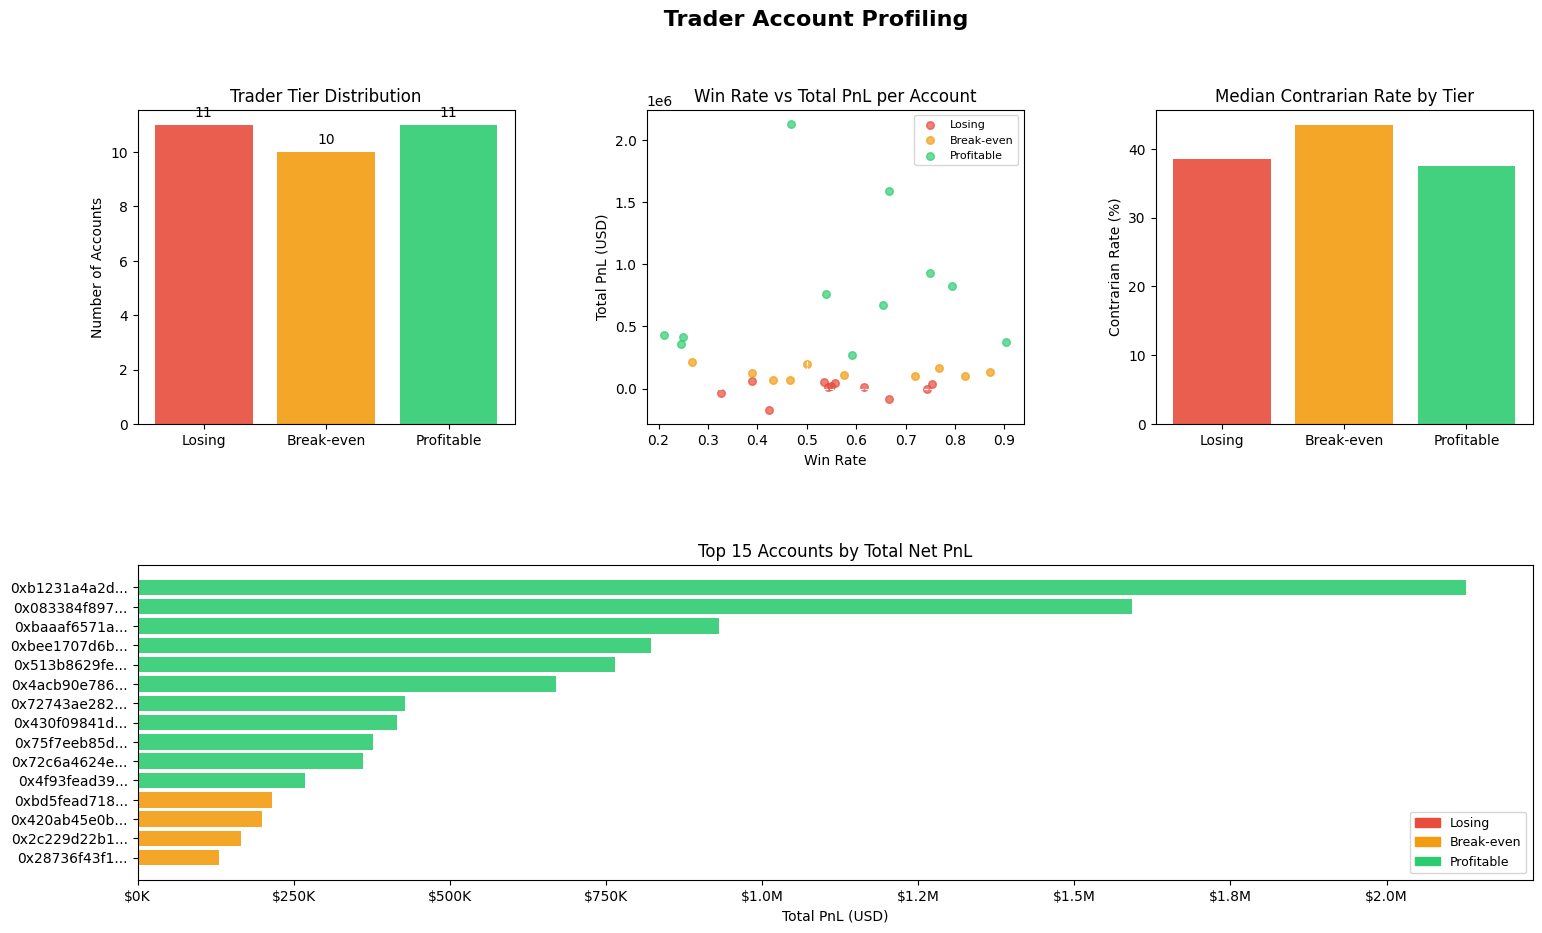

Saved: dashboard_3_trader_profiling.png


In [6]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle(' Trader Account Profiling',
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

tier_colors_list = [TIER_COLORS[t] for t in ap['trader_tier'].dropna()]

#  Panel A: Trader tier distribution 
ax_a = fig.add_subplot(gs[0, 0])
tier_counts = ap['trader_tier'].value_counts().reindex(['Losing','Break-even','Profitable'])
ax_a.bar(tier_counts.index, tier_counts.values,
         color=[TIER_COLORS[t] for t in tier_counts.index],
         edgecolor='none', alpha=0.9)
ax_a.set(title='Trader Tier Distribution', ylabel='Number of Accounts')
for i, val in enumerate(tier_counts.values):
    ax_a.text(i, val + 0.3, str(val), ha='center', fontsize=10)

#  Panel B: Win rate vs total PnL scatter
ax_b = fig.add_subplot(gs[0, 1])
for tier in ['Losing', 'Break-even', 'Profitable']:
    sub = ap[ap['trader_tier'] == tier]
    ax_b.scatter(sub['win_rate'], sub['total_pnl'],
                 color=TIER_COLORS[tier], label=tier, alpha=0.7, s=30)
ax_b.axhline(0, color='white', linewidth=0.8, linestyle='--')
ax_b.axvline(0.5, color='white', linewidth=0.8, linestyle='--')
ax_b.set(title='Win Rate vs Total PnL per Account',
         xlabel='Win Rate', ylabel='Total PnL (USD)')
ax_b.legend(fontsize=8)

#  Panel C: Contrarian rate by tier 
ax_c = fig.add_subplot(gs[0, 2])
ct_by_tier = ap.groupby('trader_tier', observed=True)['contrarian_rate'].median()
ax_c.bar(ct_by_tier.index, ct_by_tier.values * 100,
         color=[TIER_COLORS[t] for t in ct_by_tier.index],
         edgecolor='none', alpha=0.9)
ax_c.set(title='Median Contrarian Rate by Tier',
         ylabel='Contrarian Rate (%)')

#  Panel D: Top 15 accounts by total PnL 
ax_d = fig.add_subplot(gs[1, :])
top15 = ap.nlargest(15, 'total_pnl')
bar_colors_t = [TIER_COLORS.get(str(t), 'grey') for t in top15['trader_tier']]
short_labels  = [a[:12] + '...' for a in top15['account']]
bars = ax_d.barh(short_labels, top15['total_pnl'],
                 color=bar_colors_t, edgecolor='none', alpha=0.9)
ax_d.axvline(0, color='white', linewidth=0.8, linestyle='--')
ax_d.set(title='Top 15 Accounts by Total Net PnL',
         xlabel='Total PnL (USD)')
ax_d.invert_yaxis()
ax_d.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'${x/1e3:.0f}K' if abs(x) < 1e6 else f'${x/1e6:.1f}M'
))

# Legend for tiers
legend_patches = [mpatches.Patch(color=c, label=t)
                  for t, c in TIER_COLORS.items()]
ax_d.legend(handles=legend_patches, fontsize=9, loc='lower right')

plt.savefig(os.path.join(FIG_DIR, 'dashboard_3_trader_profiling.png'))
plt.show()
print('Saved: dashboard_3_trader_profiling.png')

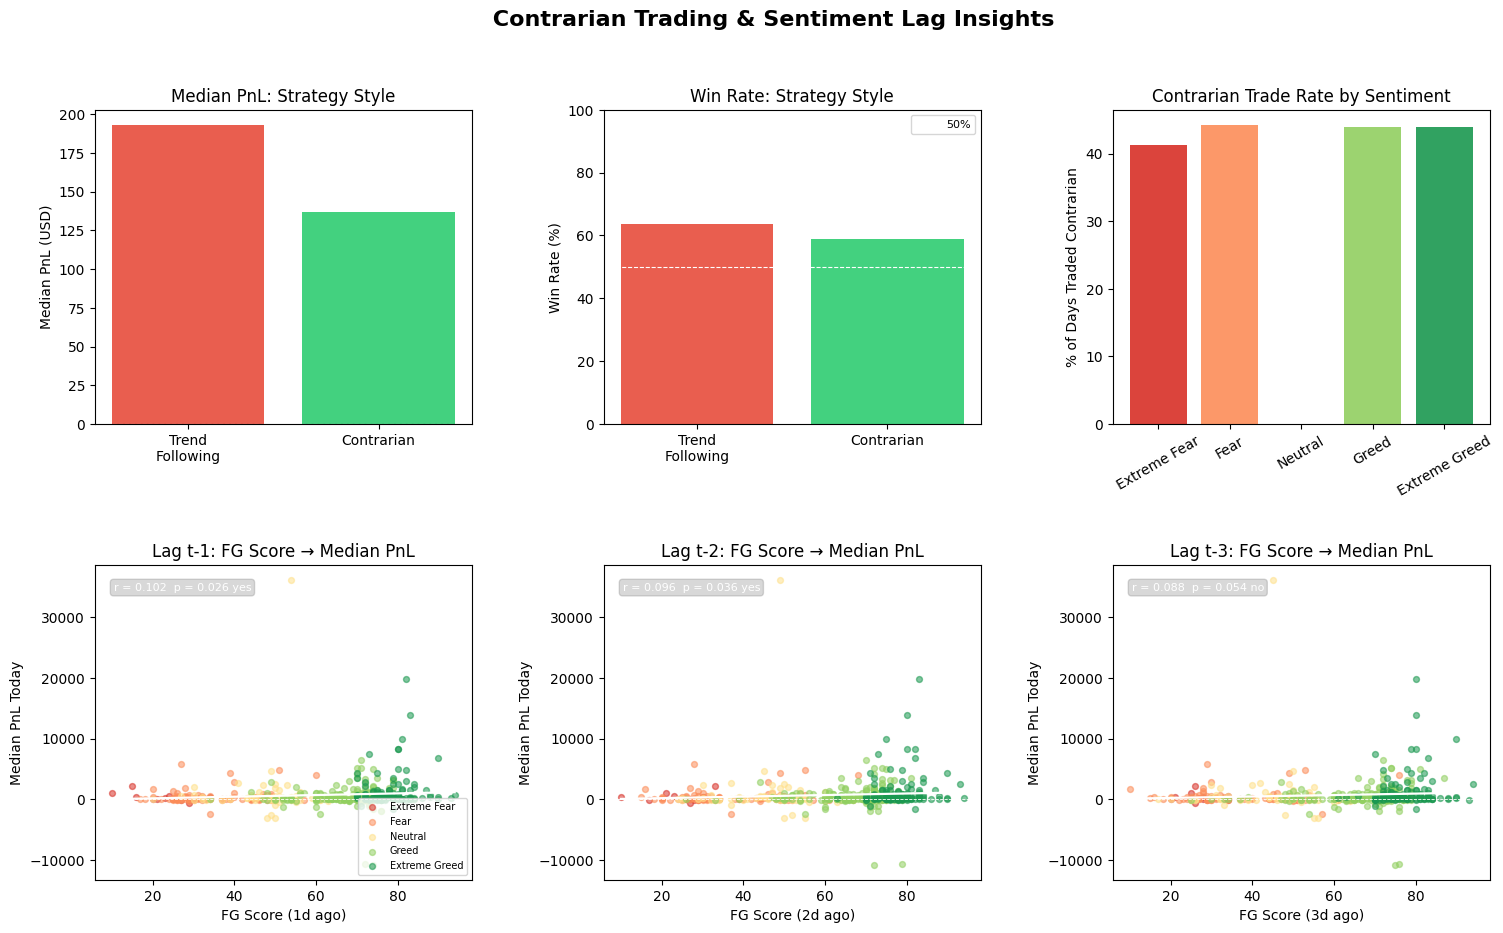

Saved: dashboard_4_contrarian_lag.png


In [7]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle(' Contrarian Trading & Sentiment Lag Insights',
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel A: Contrarian vs trend-following median PnL
ax_a = fig.add_subplot(gs[0, 0])
ct_summary = (
    df.groupby('is_contrarian')
    .agg(median_pnl=('net_pnl_w','median'), win_rate=('is_win','mean'))
    .reset_index()
)
ct_summary['label'] = ct_summary['is_contrarian'].map({0:'Trend\nFollowing', 1:'Contrarian'})
ax_a.bar(ct_summary['label'], ct_summary['median_pnl'],
         color=['#e74c3c','#2ecc71'], edgecolor='none', alpha=0.9)
ax_a.axhline(0, color='white', linewidth=0.8, linestyle='--')
ax_a.set(title='Median PnL: Strategy Style', ylabel='Median PnL (USD)')

# Panel B: Contrarian win rate vs trend-following 
ax_b = fig.add_subplot(gs[0, 1])
ax_b.bar(ct_summary['label'], ct_summary['win_rate'] * 100,
         color=['#e74c3c','#2ecc71'], edgecolor='none', alpha=0.9)
ax_b.axhline(50, color='white', linewidth=0.8, linestyle='--', label='50%')
ax_b.set(title='Win Rate: Strategy Style',
         ylabel='Win Rate (%)', ylim=(0, 100))
ax_b.legend(fontsize=8)

# Panel C: Contrarian rate by sentiment label 
ax_c = fig.add_subplot(gs[0, 2])
ct_rate = (
    df.groupby('fg_label', observed=True)['is_contrarian']
    .mean() * 100
).reindex(SENTIMENT_ORDER)
ax_c.bar(ct_rate.index, ct_rate.values,
         color=SENTIMENT_COLORS, edgecolor='none', alpha=0.9)
ax_c.set(title='Contrarian Trade Rate by Sentiment',
         ylabel='% of Days Traded Contrarian')
ax_c.tick_params(axis='x', rotation=30)

#  Panel D–F: Lag scatter t-1, t-2, t-3 
for col_idx, lag in enumerate([1, 2, 3]):
    ax = fig.add_subplot(gs[1, col_idx])
    x = daily[f'fg_lag{lag}']
    y = daily['median_pnl']

    # Colour points by current label
    for label in SENTIMENT_ORDER:
        mask = daily['fg_label'] == label
        ax.scatter(x[mask], y[mask],
                   color=COLOR_MAP[label], s=18, alpha=0.55, label=label)

    # Regression
    m, b, r, p, _ = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m * xline + b, color='white', linewidth=1.6)
    ax.axhline(0, color='white', linewidth=0.6, linestyle='--')

    sig = 'yes' if p < 0.05 else 'no'
    ax.text(0.05, 0.92,
            f'r = {r:.3f}  p = {p:.3f} {sig}',
            transform=ax.transAxes, fontsize=8, color='white',
            bbox=dict(boxstyle='round', alpha=0.3, color='grey'))
    ax.set(title=f'Lag t-{lag}: FG Score → Median PnL',
           xlabel=f'FG Score ({lag}d ago)', ylabel='Median PnL Today')
    if col_idx == 0:
        ax.legend(fontsize=7, ncol=1, loc='lower right')

plt.savefig(os.path.join(FIG_DIR, 'dashboard_4_contrarian_lag.png'))
plt.show()
print('Saved: dashboard_4_contrarian_lag.png')

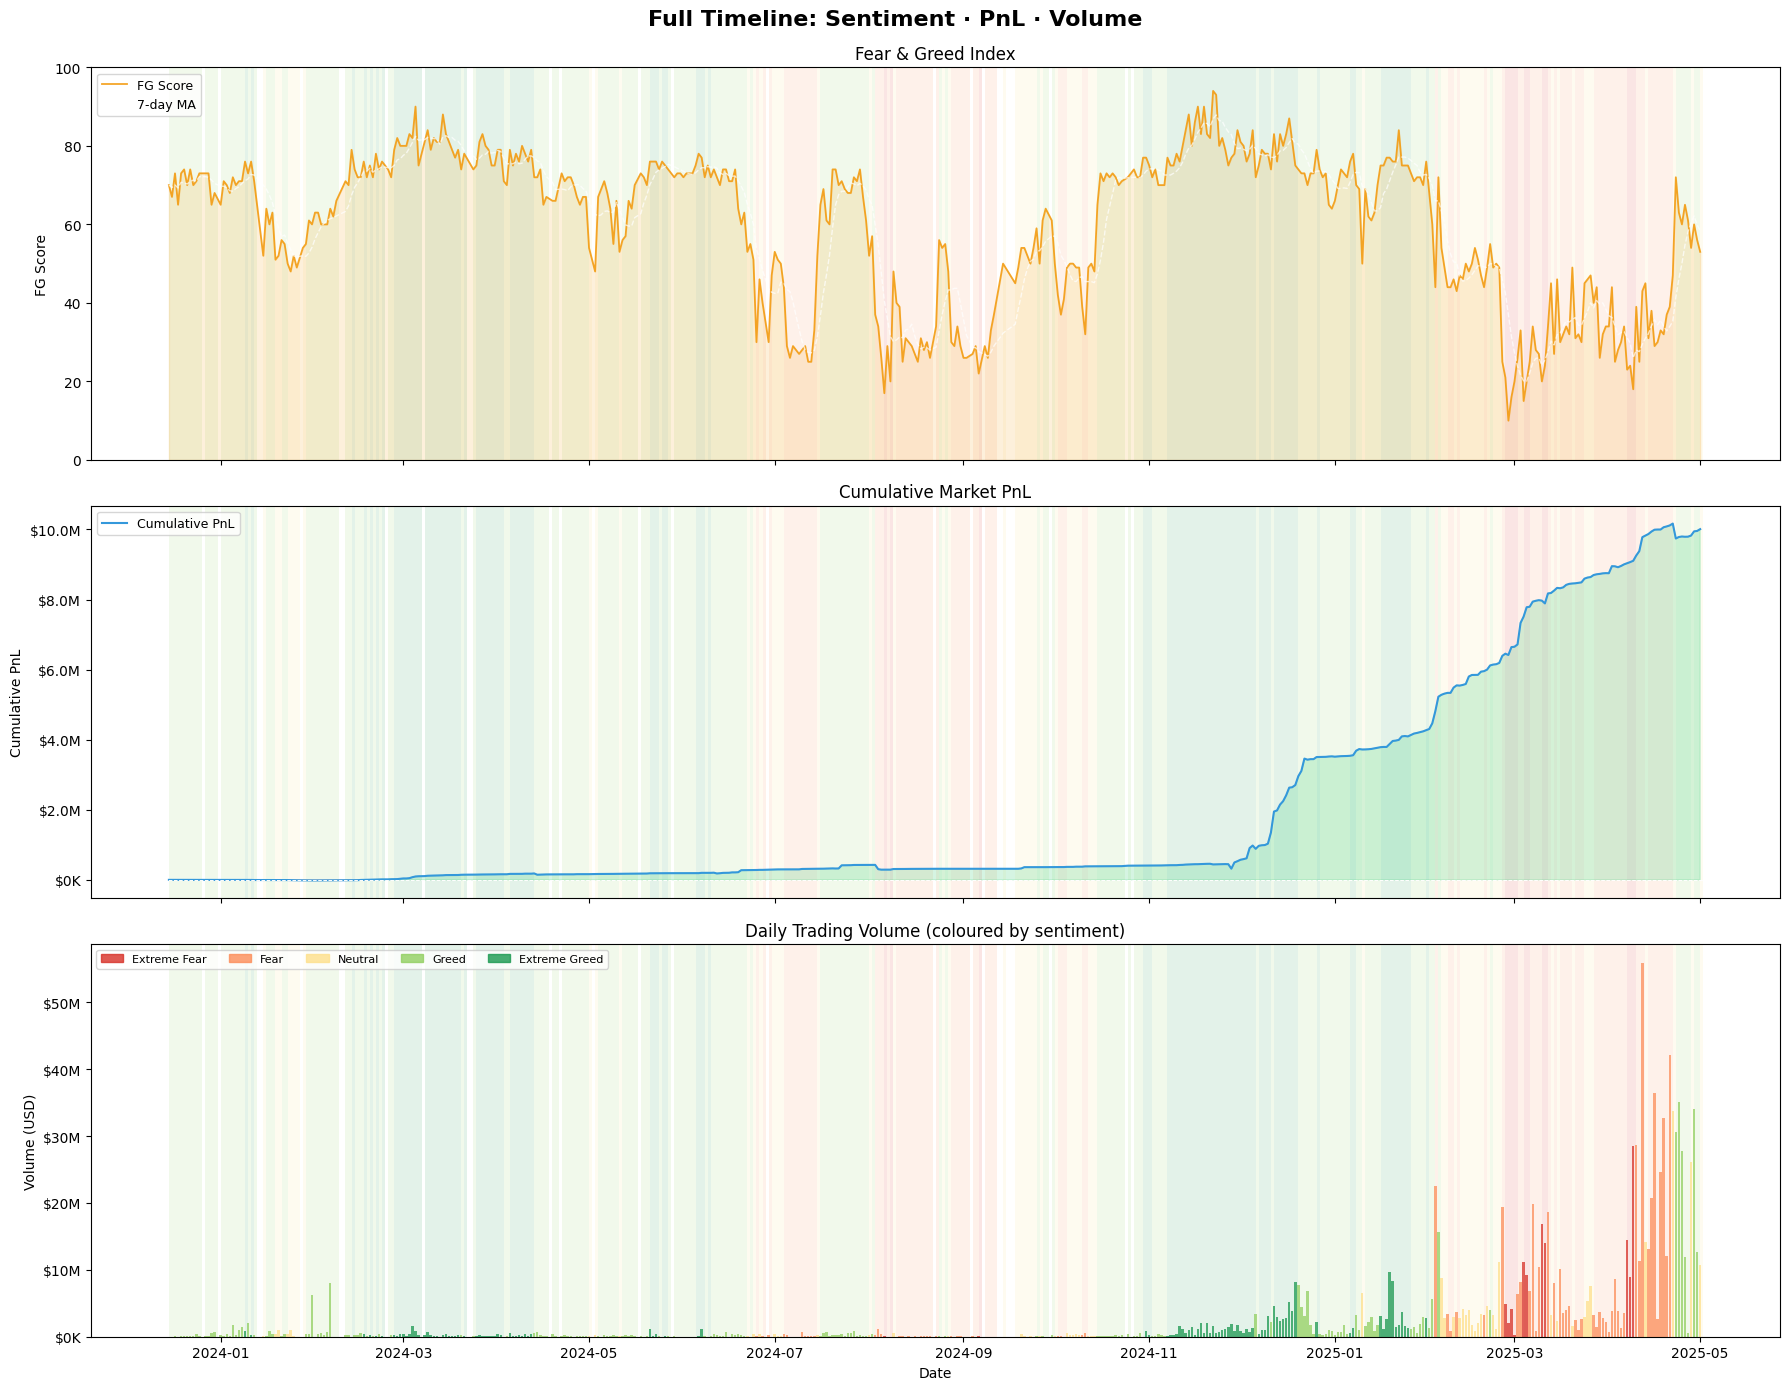

 Saved: dashboard_5_full_timeline.png


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True)
fig.suptitle('Full Timeline: Sentiment · PnL · Volume',
             fontsize=16, fontweight='bold', y=0.99)

# Sentiment background for all panels 
for ax in axes:
    for _, row in daily.iterrows():
        ax.axvspan(row['date'],
                   row['date'] + pd.Timedelta(days=1),
                   color=COLOR_MAP.get(str(row['fg_label']), 'grey'),
                   alpha=0.12, linewidth=0)

#  Row 1: FG Score 
axes[0].plot(daily['date'], daily['fg_value'],
             color='#f39c12', linewidth=1.3, alpha=0.9, label='FG Score')
axes[0].plot(daily['date'], daily['fg_7d_ma'],
             color='white', linewidth=1.0, linestyle='--', alpha=0.7, label='7-day MA')
axes[0].set(ylabel='FG Score', ylim=(0, 100), title='Fear & Greed Index')
axes[0].legend(fontsize=9, loc='upper left')
axes[0].fill_between(daily['date'], daily['fg_value'], alpha=0.15, color='#f39c12')

#  Row 2: Cumulative PnL 
cum_pnl = daily['total_pnl'].cumsum()
axes[1].plot(daily['date'], cum_pnl,
             color='#3498db', linewidth=1.5, label='Cumulative PnL')
axes[1].axhline(0, color='white', linewidth=0.7, linestyle='--')
axes[1].fill_between(daily['date'], cum_pnl, 0,
                     where=(cum_pnl >= 0), alpha=0.2, color='#2ecc71')
axes[1].fill_between(daily['date'], cum_pnl, 0,
                     where=(cum_pnl < 0), alpha=0.2, color='#e74c3c')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'${x/1e6:.1f}M' if abs(x) >= 1e6 else f'${x/1e3:.0f}K'
))
axes[1].set(ylabel='Cumulative PnL', title='Cumulative Market PnL')
axes[1].legend(fontsize=9, loc='upper left')

# Row 3: Daily volume bars
bar_colors_v = [COLOR_MAP.get(str(l), 'grey') for l in daily['fg_label']]
axes[2].bar(daily['date'], daily['total_volume'],
            color=bar_colors_v, alpha=0.75, width=0.8)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'${x/1e6:.0f}M' if abs(x) >= 1e6 else f'${x/1e3:.0f}K'
))
axes[2].set(ylabel='Volume (USD)', title='Daily Trading Volume (coloured by sentiment)')
axes[2].set_xlabel('Date')

# Shared sentiment legend
patches = [mpatches.Patch(color=c, label=l, alpha=0.8)
           for l, c in COLOR_MAP.items()]
axes[2].legend(handles=patches, fontsize=8, ncol=5, loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dashboard_5_full_timeline.png'))
plt.show()
print(' Saved: dashboard_5_full_timeline.png')

In [9]:
print('\n All figures saved to ../figures/')
for f in sorted(os.listdir(FIG_DIR)):
    print(f'   ├── {f}')


 All figures saved to ../figures/
   ├── dashboard_1_sentiment_overview.png
   ├── dashboard_2_performance_vs_sentiment.png
   ├── dashboard_3_trader_profiling.png
   ├── dashboard_4_contrarian_lag.png
   ├── dashboard_5_full_timeline.png
